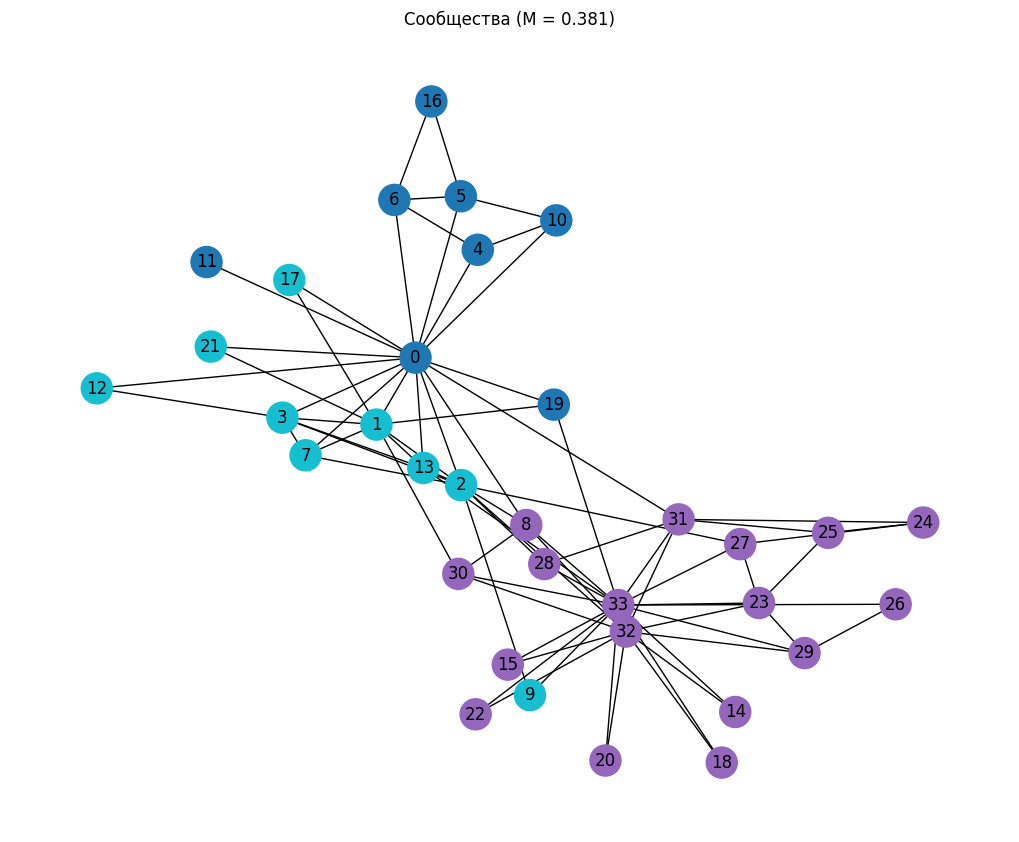

In [8]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy

#визуализация
G=nx.karate_club_graph()
N=G.number_of_nodes()
L=G.number_of_edges()

#Шаг 1
communities=[]
for i in range(N):
    community={i}
    communities.append(community)

def modularity(G, communities):
    L=G.number_of_edges()
    M=0.0

    for c in communities:
        subgraph=G.subgraph(c)
        L_c=subgraph.number_of_edges()
        k_c=sum(dict(G.degree(c)).values())
        M_c=(L_c/L)-((k_c/(2*L))**2)
        M+=M_c
    return M

def delta_M(G, community_a, community_b, L):
    L_AB=0
    for node_a in community_a:
        for node_b in community_b:
            if G.has_edge(node_a, node_b):
                L_AB+=1
    k_A=sum(dict(G.degree(community_a)).values())
    k_B=sum(dict(G.degree(community_b)).values())
    return (L_AB/L)-(k_A*k_B)/(2*L**2)

#Шаг 2 и 3
best_modularity=-float('inf')
best_communities=None
current=[set(comm) for comm in communities]  #копия

while len(current)>1:
    best_delta=-float('inf')
    best_i, best_j=-1, -1

    for i in range(len(current)):
        for j in range(i+1, len(current)):
            d=delta_M(G, current[i], current[j], L)
            if d>best_delta:
                best_delta=d
                best_i, best_j=i, j

    new_comm=current[best_i] | current[best_j]
    new_list=[]
    for idx, comm in enumerate(current):
        if idx!=best_i and idx!=best_j:
            new_list.append(comm)
    new_list.append(new_comm)
    current=new_list

    #Шаг 4
    M=modularity(G, current)
    if M>best_modularity:
        best_modularity=M
        best_communities=[set(comm) for comm in current]

#раскрасить узлы в цвета сообществ
color_dict={}
for idx, comm in enumerate(best_communities):
    for node in comm:
        color_dict[node]=idx
colors=[color_dict[node] for node in G.nodes()]

#визуализация сети
plt.figure(figsize=(10, 8))
pos=nx.spring_layout(G, seed=42)
nx.draw(G, pos,
        node_color=colors,
        cmap=plt.cm.tab10_r,
        with_labels=True,
        node_size=500)
plt.title(f"Сообщества (M = {best_modularity:.3f})")
plt.show()